<a href="https://colab.research.google.com/github/mororrrr/Ecommerce/blob/main/Ecommerce_DW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# 1. قراءة الملف
df = pd.read_csv('sample_data/fact_orders.csv')

# 2. إزالة التكرار (عشان الـ Primary Key ميضربش في SQL)
df = df.drop_duplicates(subset=['Order_ID'])

# 3. إزالة أيام التوصيل الشاذة/السالبة (زي -2 اللي الـ SQL استبعدها)
df = df[df['Delivery_Days'] >= 0]

# 4. ملء الخانات الفاضية في الأرقام والمبالغ بـ 0 بدلاً من NaN
money_cols = [
    'Gross_Sales',
    'Net_Sales',
    'Profit',
    'Shipping_Cost',
    'Refund_Amount',
    'Marketing_Cost',
    'COGS',
]
df[money_cols] = df[money_cols].fillna(0)

# 5. تقريب الأرقام لخانة أو خانتين لتتناسب مع DECIMAL في SQL
df[money_cols] = df[money_cols].round(2)

# 6. تصدير الملف النظيف جاهز للرفع على الـ SQL
df.to_csv('clean_fact_orders.csv', index=False)
print('تم تنظيف fact_orders بنجاح!')

تم تنظيف fact_orders بنجاح!


In [ ]:
# تنظيف جدول حالات الطلب
df_status = pd.read_csv('sample_data/dim_order_status.csv')
df_status['Order_Status'] = df_status['Order_Status'].fillna('Unknown')
df_status.drop_duplicates(subset=['Order_Status_Key'], inplace=True)
df_status.to_csv('clean_dim_order_status.csv', index=False)

# تنظيف جدول التسويق (لو الحملة الإعلانية فاضية)
df_marketing = pd.read_csv('sample_data/dim_marketing.csv')
df_marketing['Campaign'] = df_marketing['Campaign'].fillna('No Campaign')
df_marketing.drop_duplicates(subset=['Marketing_Key'], inplace=True)
df_marketing.to_csv('clean_dim_marketing.csv', index=False)

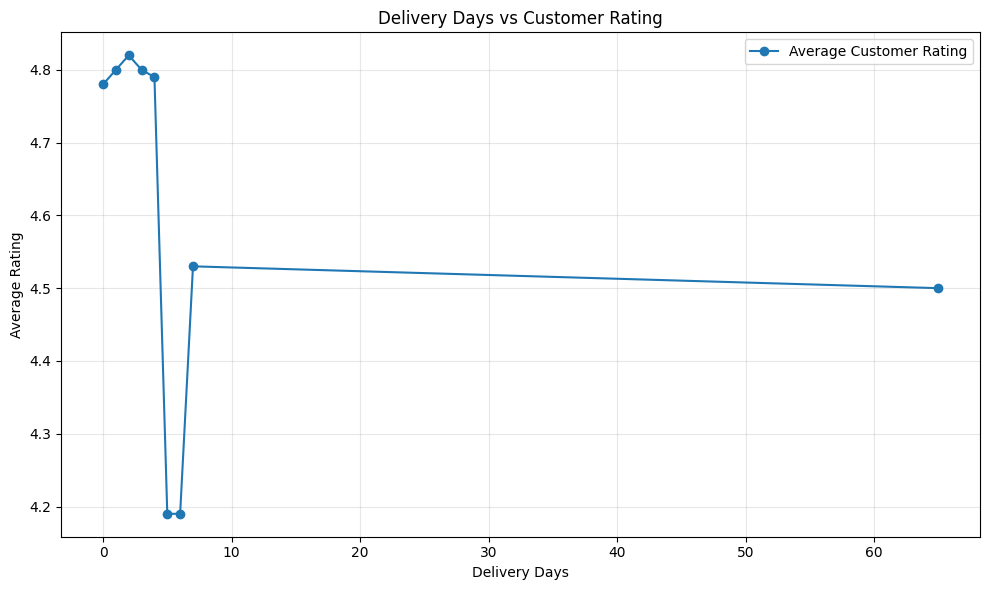

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import zipfile


# =========================================================
# 1) Load Data
# =========================================================



marketing = pd.read_csv(
        'sample_data/clean_dim_marketing.csv')

# =========================================================
# Q1
# Delivery Days vs Customer Rating & Refunds
# =========================================================

q1 = fact[fact["Delivery_Days"] >= 0].groupby("Delivery_Days").agg(
    Avg_Rating=("Customer_Rating", "mean"),
    Avg_Refund=("Refund_Amount", "mean"),
    Total_Orders=("Order_ID", "count")
).reset_index()

q1["Avg_Rating"] = q1["Avg_Rating"].round(2)
q1["Avg_Refund"] = q1["Avg_Refund"].round(2)


plt.figure(figsize=(10, 6))

plt.plot(
    q1["Delivery_Days"],
    q1["Avg_Rating"],
    marker="o",
    label="Average Customer Rating"
)

plt.xlabel("Delivery Days")
plt.ylabel("Average Rating")
plt.title("Delivery Days vs Customer Rating")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()



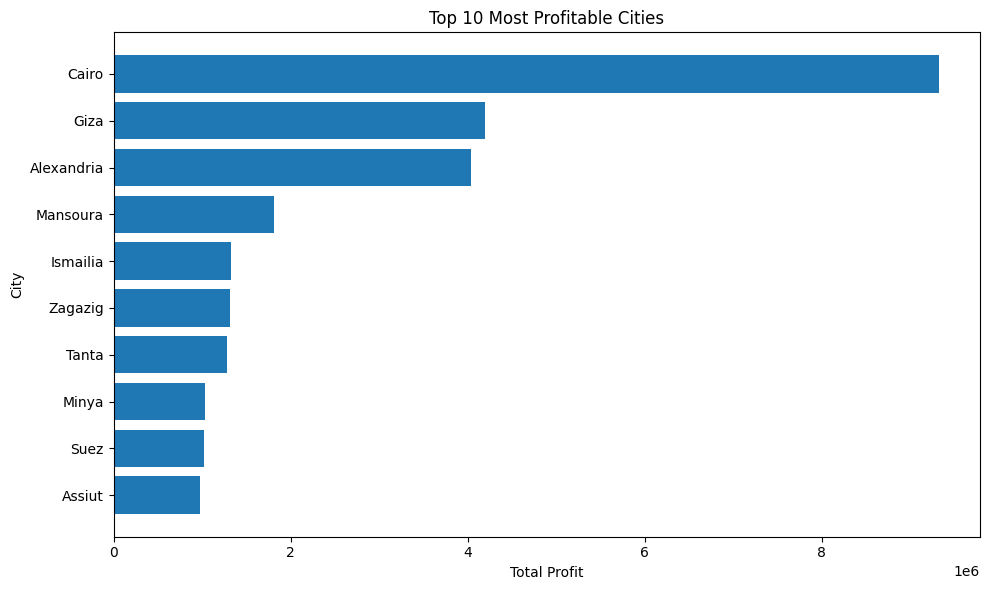

In [ ]:

# =========================================================
# Q2
# Most Profitable Cities
# =========================================================

q2 = fact.merge(
    geography,
    on="Geography_Key"
)

q2 = q2.groupby("City").agg(
    Total_Profit=("Profit", "sum"),
    Total_Net_Sales=("Net_Sales", "sum")
).reset_index()

q2 = q2.sort_values("Total_Profit", ascending=False)

# Top 10 cities فقط عشان الرسم يبقى واضح
top_cities = q2.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_cities["City"],
    top_cities["Total_Profit"]
)

plt.xlabel("Total Profit")
plt.ylabel("City")
plt.title("Top 10 Most Profitable Cities")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


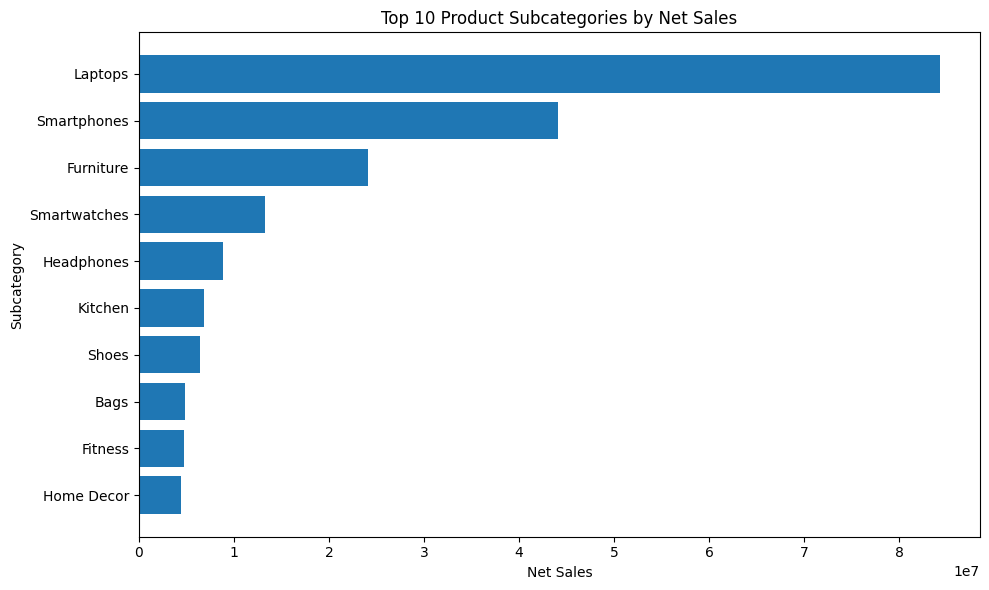

In [ ]:

# =========================================================
# Q3
# Top Product Categories & Subcategories
# =========================================================

q3 = fact.merge(
    product,
    on="Product_Key"
)

q3 = q3.groupby(
    ["Category", "Subcategory"]
).agg(
    Units_Sold=("Quantity", "sum"),
    Total_Net_Sales=("Net_Sales", "sum"),
    Total_Profit=("Profit", "sum")
).reset_index()

q3 = q3.sort_values(
    "Total_Net_Sales",
    ascending=False
)

# Top 10 subcategories
top_products = q3.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_products["Subcategory"],
    top_products["Total_Net_Sales"]
)

plt.xlabel("Net Sales")
plt.ylabel("Subcategory")
plt.title("Top 10 Product Subcategories by Net Sales")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()



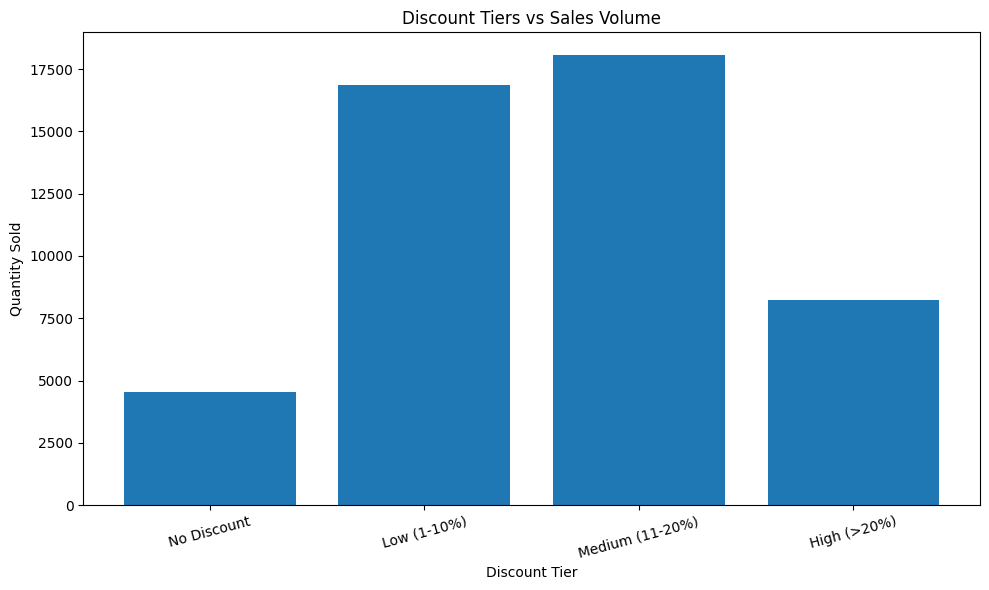

In [ ]:
# =========================================================
# Q4
# Discount Tiers vs Sales Volume & Profit
# =========================================================
fact_clean = pd.read_csv('sample_data/clean_fact_orders.csv')

def discount_tier(rate):

    if rate == 0:
        return "No Discount"

    elif rate <= 0.10:
        return "Low (1-10%)"

    elif rate <= 0.20:
        return "Medium (11-20%)"

    else:
        return "High (>20%)"


fact["Discount_Tier"] = fact["Discount_Rate"].apply(discount_tier)


q4 = fact.groupby("Discount_Tier").agg(
    Order_Count=("Order_ID", "count"),
    Total_Quantity=("Quantity", "sum"),
    Total_Net_Sales=("Net_Sales", "sum"),
    Total_Profit=("Profit", "sum")
).reset_index()


# ترتيب منطقي للـdiscount
order = [
    "No Discount",
    "Low (1-10%)",
    "Medium (11-20%)",
    "High (>20%)"
]

q4["Discount_Tier"] = pd.Categorical(
    q4["Discount_Tier"],
    categories=order,
    ordered=True
)

q4 = q4.sort_values("Discount_Tier")


plt.figure(figsize=(10, 6))

plt.bar(
    q4["Discount_Tier"],
    q4["Total_Quantity"]
)

plt.xlabel("Discount Tier")
plt.ylabel("Quantity Sold")
plt.title("Discount Tiers vs Sales Volume")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()



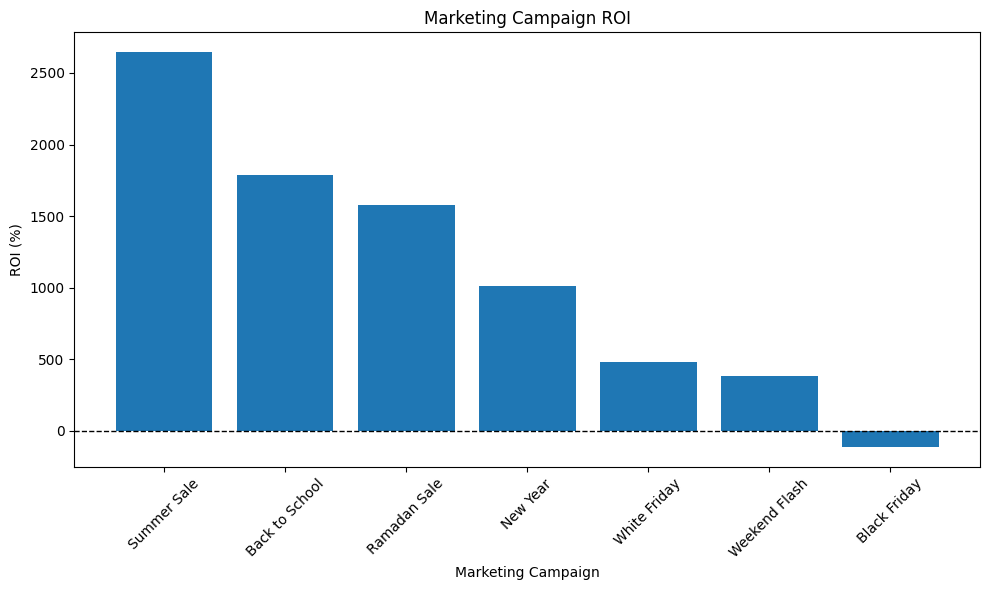

In [ ]:
# 1) قراءة البيانات المنظفة مباشرة من المسار الرئيسي
fact_clean = pd.read_csv('sample_data/clean_fact_orders.csv')
marketing_clean = pd.read_csv('sample_data/clean_dim_marketing.csv')

# 2) دمج جدول الـ Fact النظيف مع جدول الـ Marketing النظيف
q5 = fact_clean.merge(
    marketing_clean,
    on="Marketing_Key"
)

# 3) استبعاد القيم الفارغة في اسم الحملة
# استبعاد المبيعات العادية وحصر التحليل على الحملات الفعلية
q5 = q5[(q5["Campaign"].notna()) & (q5["Campaign"] != "No Campaign")]

# 4) التجميع وحساب التكاليف والأرباح
q5 = q5.groupby("Campaign").agg(
    Total_Orders=("Order_ID", "count"),
    Total_Marketing_Cost=("Marketing_Cost", "sum"),
    Total_Profit=("Profit", "sum")
).reset_index()

# 5) حساب العائد على الاستثمار ROI
q5["ROI_Pct"] = (
    (q5["Total_Profit"] - q5["Total_Marketing_Cost"])
    / q5["Total_Marketing_Cost"]
) * 100

# 6) الترتيب من الأعلى للأقل
q5 = q5.sort_values("ROI_Pct", ascending=False)

# =========================================================
# Visualization
# =========================================================
plt.figure(figsize=(10, 6))

plt.bar(
    q5["Campaign"],
    q5["ROI_Pct"]
)

plt.xlabel("Marketing Campaign")
plt.ylabel("ROI (%)")
plt.title("Marketing Campaign ROI")
plt.xticks(rotation=45)
plt.axhline(y=0, color='black', linewidth=1, linestyle='--')

plt.tight_layout()
plt.show()